In [1]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

from pdm_learn.preprocessing import densitymap
from pdm_learn.simulation import build_heatmap_dataset, build_metric_dataset, perturb_pair


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from bisect import bisect_left

In [4]:
positive = pd.read_csv(DATA_DIR / 'simulated' / 'positive.csv').reset_index(drop=True)

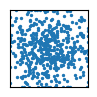

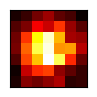

In [23]:
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

SIM_CENTERS = np.linspace(-2, 2, 7)
EPSILON_STD = 2.0
NEGATIVE_REPEATS = 200
HEATMAP_SIGMA = 0.1
RANDOM_SEED = 42

def compute_mi(x, y):
    return mutual_info_regression(x.reshape(-1, 1), y, discrete_features=False)[0]

def bicor(x, y, c=9.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        return np.nan
    x_med = np.median(x)
    y_med = np.median(y)
    x_mad = np.median(np.abs(x - x_med))
    y_mad = np.median(np.abs(y - y_med))
    if x_mad == 0 or y_mad == 0:
        return np.nan
    ux = (x - x_med) / (c * x_mad)
    uy = (y - y_med) / (c * y_mad)
    wx = (1 - ux**2)**2
    wy = (1 - uy**2)**2
    wx[np.abs(ux) >= 1] = 0
    wy[np.abs(uy) >= 1] = 0
    xw = (x - x_med) * wx
    yw = (y - y_med) * wy
    numerator = np.sum(xw * yw)
    denominator = np.sqrt(np.sum(xw**2) * np.sum(yw**2))
    return numerator / denominator if denominator != 0 else np.nan

rng = np.random.default_rng(RANDOM_SEED)
preview_x = positive.iloc[60].to_numpy()
preview_y = positive.iloc[61].to_numpy()
preview_x, preview_y = perturb_pair(preview_x, preview_y, EPSILON_STD, centers=SIM_CENTERS, rng=rng)

plt.figure(figsize=(1, 1))
plt.scatter(preview_x, preview_y, s=2)
plt.xlim(min(SIM_CENTERS), max(SIM_CENTERS))
plt.ylim(min(SIM_CENTERS), max(SIM_CENTERS))
plt.xticks([])
plt.yticks([])
plt.show()

preview_map = densitymap(preview_x, preview_y, SIM_CENTERS, SIM_CENTERS, sigma=HEATMAP_SIGMA)[::-1]
plt.figure(figsize=(1, 1))
plt.imshow(preview_map, cmap='hot', interpolation='nearest')
plt.xticks([])
plt.yticks([])
plt.show()


In [10]:
heatmap_positive = build_heatmap_dataset(
    positive,
    densitymap,
    centers=SIM_CENTERS,
    repeats=1,
    epsilon_std=EPSILON_STD,
    sigma=HEATMAP_SIGMA,
    rng=np.random.default_rng(RANDOM_SEED),
)
heatmap_positive.to_csv(DATA_DIR / 'simulated' / 'positive_heatmap.csv', index=False)

heatmap_negative = build_heatmap_dataset(
    positive,
    densitymap,
    centers=SIM_CENTERS,
    repeats=NEGATIVE_REPEATS,
    epsilon_std=EPSILON_STD,
    sigma=HEATMAP_SIGMA,
    shuffle_y=True,
    rng=np.random.default_rng(RANDOM_SEED + 1),
)
heatmap_negative.to_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv', index=False)

heatmap_positive.head()


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-3.713046,-3.461297,-3.543611,-3.192579,-3.582985,-3.771077,-3.891820,-3.708790,-3.139786,-2.911991,...,-2.936781,-3.504313,-3.292525,-3.782942,-3.727179,-3.798089,-3.484391,-3.493031,-3.487157,-3.873456
1,-3.408227,-3.388432,-3.236532,-3.281834,-3.860735,-3.556379,-3.890037,-3.624944,-3.278397,-2.898781,...,-3.126390,-3.425744,-3.495151,-3.818612,-3.685600,-3.724494,-3.615685,-3.450220,-3.891797,-3.890204
2,-3.794194,-3.808100,-3.613401,-3.156769,-3.791950,-3.891820,-3.798330,-3.576599,-3.334764,-3.068516,...,-3.255839,-3.183466,-3.703921,-3.711297,-3.637825,-3.793214,-3.256593,-3.490002,-3.457175,-3.639062
3,-3.712835,-3.429108,-3.705999,-3.065054,-3.695877,-3.773883,-3.814846,-3.688490,-3.299400,-3.074812,...,-3.053275,-3.482404,-3.490464,-3.887611,-3.558306,-3.431537,-3.425243,-3.472005,-3.525709,-3.695236
4,-3.889896,-3.446659,-3.243455,-3.677024,-3.512259,-3.633781,-3.891807,-3.445523,-3.451084,-3.096101,...,-3.054525,-3.475429,-3.524571,-3.891820,-3.797087,-3.565522,-3.690932,-3.389313,-3.519983,-3.797383


In [11]:
metric_specs = {
    'pearson': lambda x, y: pearsonr(x, y)[0],
    'spearman': lambda x, y: spearmanr(x, y)[0],
    'mi': compute_mi,
    'bicor': bicor,
}

for offset, (name, metric_fn) in enumerate(metric_specs.items(), start=10):
    positive_df = build_metric_dataset(
        positive,
        metric_fn,
        repeats=1,
        epsilon_std=EPSILON_STD,
        column_name=name.upper() if name != 'bicor' else 'BiCor',
        rng=np.random.default_rng(RANDOM_SEED + offset),
    )
    positive_df.to_csv(DATA_DIR / 'simulated' / f'positive_{name}.csv', index=False)

    negative_df = build_metric_dataset(
        positive,
        metric_fn,
        repeats=NEGATIVE_REPEATS,
        epsilon_std=EPSILON_STD,
        shuffle_y=True,
        column_name=name.upper() if name != 'bicor' else 'BiCor',
        rng=np.random.default_rng(RANDOM_SEED + 100 + offset),
    )
    negative_df.to_csv(DATA_DIR / 'simulated' / f'negative_{name}.csv', index=False)

{name: pd.read_csv(DATA_DIR / 'simulated' / f'positive_{name}.csv').head() for name in metric_specs}


{'pearson':     PEARSON
 0  0.182507
 1  0.225449
 2  0.189545
 3  0.234665
 4  0.141243,
 'spearman':    SPEARMAN
 0  0.146103
 1  0.199214
 2  0.168774
 3  0.173623
 4  0.191179,
 'mi':          MI
 0  0.000000
 1  0.015946
 2  0.006498
 3  0.051241
 4  0.061193,
 'bicor':       BiCor
 0  0.187548
 1  0.209751
 2  0.218625
 3  0.198178
 4  0.169439}

In [7]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_pearson.csv').head()


,PEARSON
0,0.487481
1,0.509297
2,0.485453
3,0.525735
4,0.455474


In [8]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_spearman.csv').head()


,SPEARMAN
0,0.483860
1,0.516349
2,0.484306
3,0.504363
4,0.512707


In [9]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_mi.csv').head()


,MI
0,0.204792
1,0.173837
2,0.124274
3,0.122284
4,0.222303


In [10]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_bicor.csv').head()


,BiCor
0,0.496839
1,0.503746
2,0.528401
3,0.498987
4,0.475570


In [11]:
pd.read_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv').head()


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-3.655654,-3.717797,-3.607322,-3.585434,-3.389758,-3.810338,-3.712837,-3.466047,-3.102957,-3.224415,...,-2.947767,-3.222858,-3.636275,-3.891820,-3.722425,-3.752013,-3.273606,-3.479521,-3.885899,-3.885848
1,-3.891143,-3.571909,-3.600578,-3.469699,-3.450831,-3.446104,-3.734979,-3.637737,-3.311594,-3.129355,...,-3.162095,-3.401560,-3.633838,-3.876518,-3.634574,-3.794947,-3.279666,-3.460267,-3.721630,-3.713019
2,-3.891820,-3.712548,-3.425822,-3.640676,-3.587574,-3.375096,-3.891818,-3.646777,-3.390439,-2.911859,...,-3.264791,-3.489558,-3.648793,-3.769509,-3.714634,-3.496921,-3.313384,-3.442378,-3.483937,-3.712848
3,-3.798330,-3.564883,-3.506205,-3.481821,-3.429168,-3.769713,-3.664172,-3.681011,-3.486442,-2.944623,...,-3.093815,-3.372533,-3.668060,-3.680568,-3.685734,-3.672905,-3.502286,-3.310353,-3.603267,-3.712448
4,-3.891820,-3.375174,-3.433155,-3.629646,-3.711863,-3.797697,-3.798330,-3.811340,-3.254779,-2.979299,...,-3.126473,-3.069497,-3.798270,-3.798037,-3.634336,-3.347650,-3.328543,-3.448180,-3.888958,-3.798330


In [13]:
plt.imshow(positive_df.iloc[100, :].to_numpy().reshape(7,7), cmap='hot', interpolation='nearest')
plt.show()

IndexError: single positional indexer is out-of-bounds